In [1]:
import numpy as np
import sleap
import matplotlib.pyplot as plt
import sys, os
sys.path.append('../..')
from python.postprocess import *

In [2]:
original_dataset = sleap.load_file('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp')
original_dataset

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)

In [8]:
# results_affix = range(9)
# results_affix = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
# results_affix = ['m1t1', 'm5t1', 'm6t1', 'm9t1', 'm9t2', 'm9t3', 'm9t4', 'm9t5', 'm9t6', 'm9t7', 'm9t8', 'm9t9', 'm7t2']
results_affix = ['m10t1', 'm10t2', 'm10t3']
all_predicted_pointss = []
results_dir = '../results/r3/'
existing_results = os.listdir(results_dir)
for affix in results_affix:
    print(f'affix: {affix}')
    try:
        denoised_coords = np.load(os.path.join(results_dir, f'prediction_{affix}.npy'))
    except:
        continue
    print(denoised_coords.shape)
    if denoised_coords.shape != (9000, 17, 2):
        denoised_coords = denoised_coords.reshape((9000, 17, 2)) * [170, 174]
    if f'predicted_dataset_{affix}.slp' not in existing_results:
    # if affix == 19:
        predicted_dataset = dataset_with_new_points(original_dataset, denoised_coords, 
                                                    node_name='tb', handle_first_frame=False, start_idx=0)
        predicted_dataset.save(os.path.join(results_dir, f'predicted_dataset_{affix}.slp'))
    all_predicted_pointss.append(denoised_coords)

affix: m10t1
(9000, 17, 2)
affix: m10t2
(9000, 17, 2)
affix: m10t3
(9000, 17, 2)
missing_pt_cnt: 0


In [4]:
corrected_points_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
y_true = np.load(corrected_points_path)
print(y_true.shape)

(9000, 17, 2)


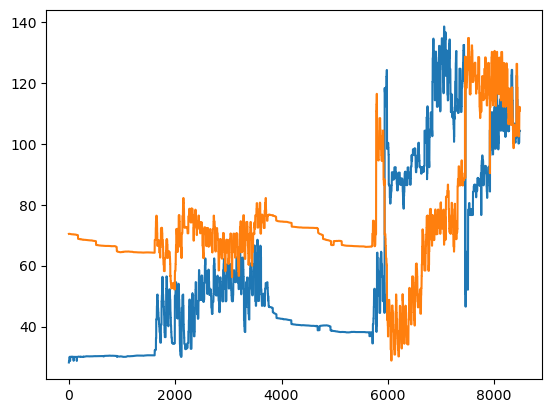

In [5]:
x_test = y_true[:, 0, 0]
y_test = y_true[:, 0, 1]
plt.plot(x_test[x_test != 0])
plt.plot(y_test[y_test != 0])


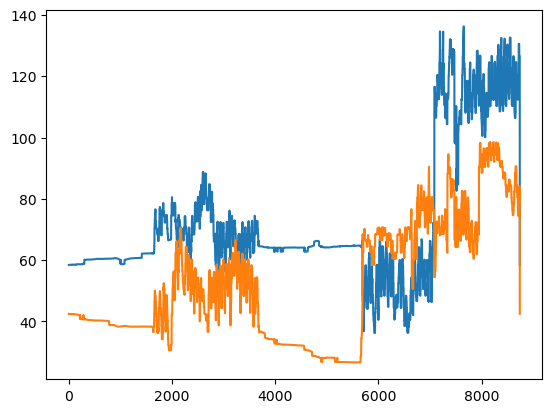

In [6]:
pt_idx = 2
x_test = y_true[:, pt_idx, 0]
y_test = y_true[:, pt_idx, 1]
plt.plot(x_test[x_test != 0])
plt.plot(y_test[y_test != 0])

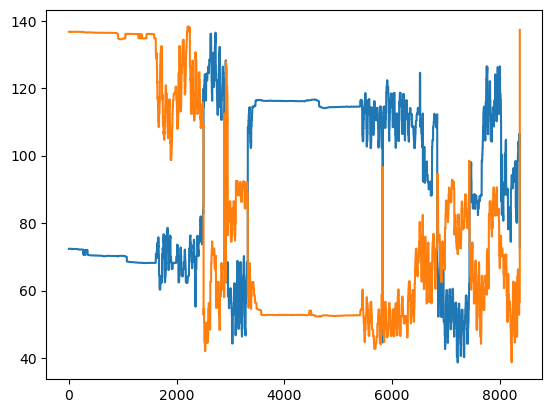

In [7]:
pt_idx = 8
x_test = y_true[:, pt_idx, 0]
y_test = y_true[:, pt_idx, 1]
plt.plot(x_test[x_test != 0])
plt.plot(y_test[y_test != 0])

find 2 nearest neighbors over a sliding window 

use large window, find where it's expanded, assign order based on nearest neighbor

In [9]:
def get_diff(y_true, predicted_points):
    diff = np.sum(np.linalg.norm(y_true[:2500] - predicted_points[:2500], axis=-1)) / (2500 * 17)
    return diff

for affix, predicted_points in zip(results_affix, all_predicted_pointss):
    diff = get_diff(y_true, predicted_points)
    print(f'{affix}: {diff:.4f}')


m10t1: 128.4336
m10t2: 128.4337
m10t3: 3.4629


In [2]:
c0_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
c0_dataset = sleap.load_file(c0_dataset_path)
print(c0_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [5]:
c0_points = get_all_tracked_points(original_dataset, reorder=False, interpolate=False, start_idx=0, min_score=0.6)
print(c0_points.shape)

all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
(9000, 17, 2)


In [4]:
c0_tracking_dataset = dataset_with_new_points(original_dataset, c0_points, node_name='tb', handle_first_frame=False, start_idx=0)
c0_tracking_dataset.save('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/v2_c0_training.slp')

missing_pt_cnt: 7440


In [7]:
predicted_pt1 = all_predicted_pointss[0]
predicted_pt1[0]

array([[169.99912858, 173.99939847],
       [169.99945283, 173.99825764],
       [169.99933124, 173.99798799],
       [169.99868274, 173.99898362],
       [169.998703  , 173.99927402],
       [169.99931097, 173.99813318],
       [169.99914885, 173.99861026],
       [169.99918938, 173.998631  ],
       [169.99933124, 173.99904585],
       [169.99904752, 173.99856877],
       [169.99858141, 173.99902511],
       [169.99858141, 173.99941921],
       [169.99864221, 173.9994607 ],
       [169.99872327, 173.99906659],
       [169.99878407, 173.99952292],
       [169.99872327, 173.99910808],
       [169.99787211, 173.99834061]])